In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [5]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [6]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [7]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [8]:
train_box(box_model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 50 concetti unici e 583 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.4475
Epoca [10/100] | Loss: 0.1995
Epoca [20/100] | Loss: 0.0569
Epoca [30/100] | Loss: 0.0236
Epoca [40/100] | Loss: 0.0118
Epoca [50/100] | Loss: 0.0071
Epoca [60/100] | Loss: 0.0050
Epoca [70/100] | Loss: 0.0041
Epoca [80/100] | Loss: 0.0036
Epoca [90/100] | Loss: 0.0032
Epoca [100/100] | Loss: 0.0030

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: lower_body_part | big
 - P_teorica: 0.0 -> P_predetta: 0.0144
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


### Visualization

In [9]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

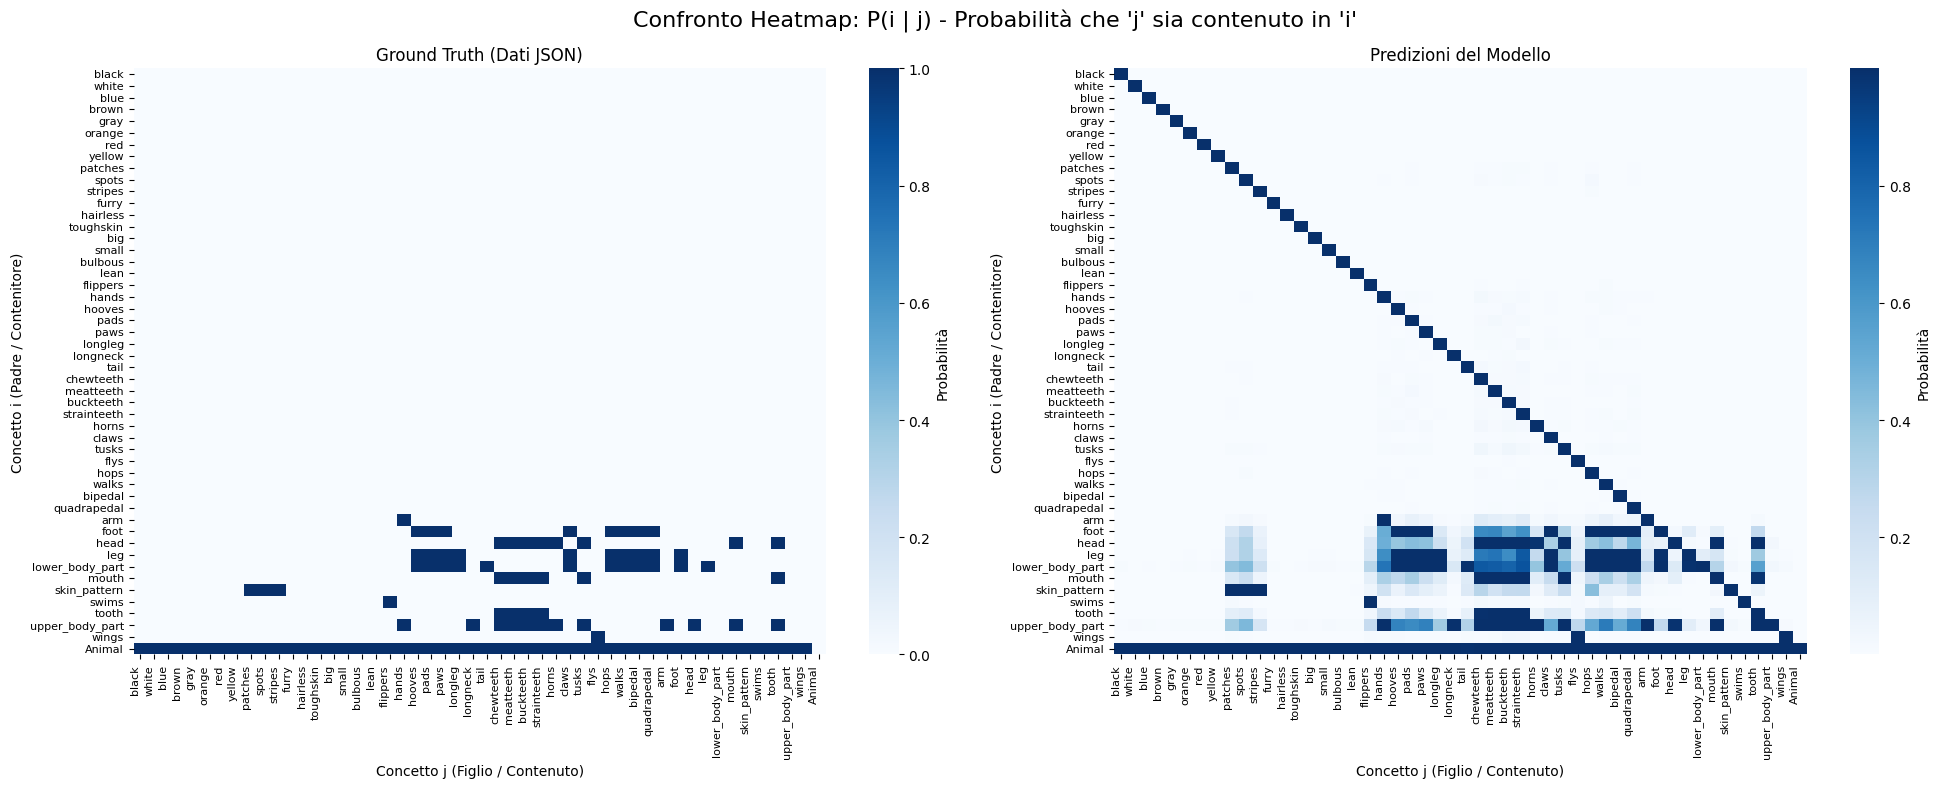

In [10]:
visualize_heatmap_compare(box_model, dataset, concept2id, id2concept)

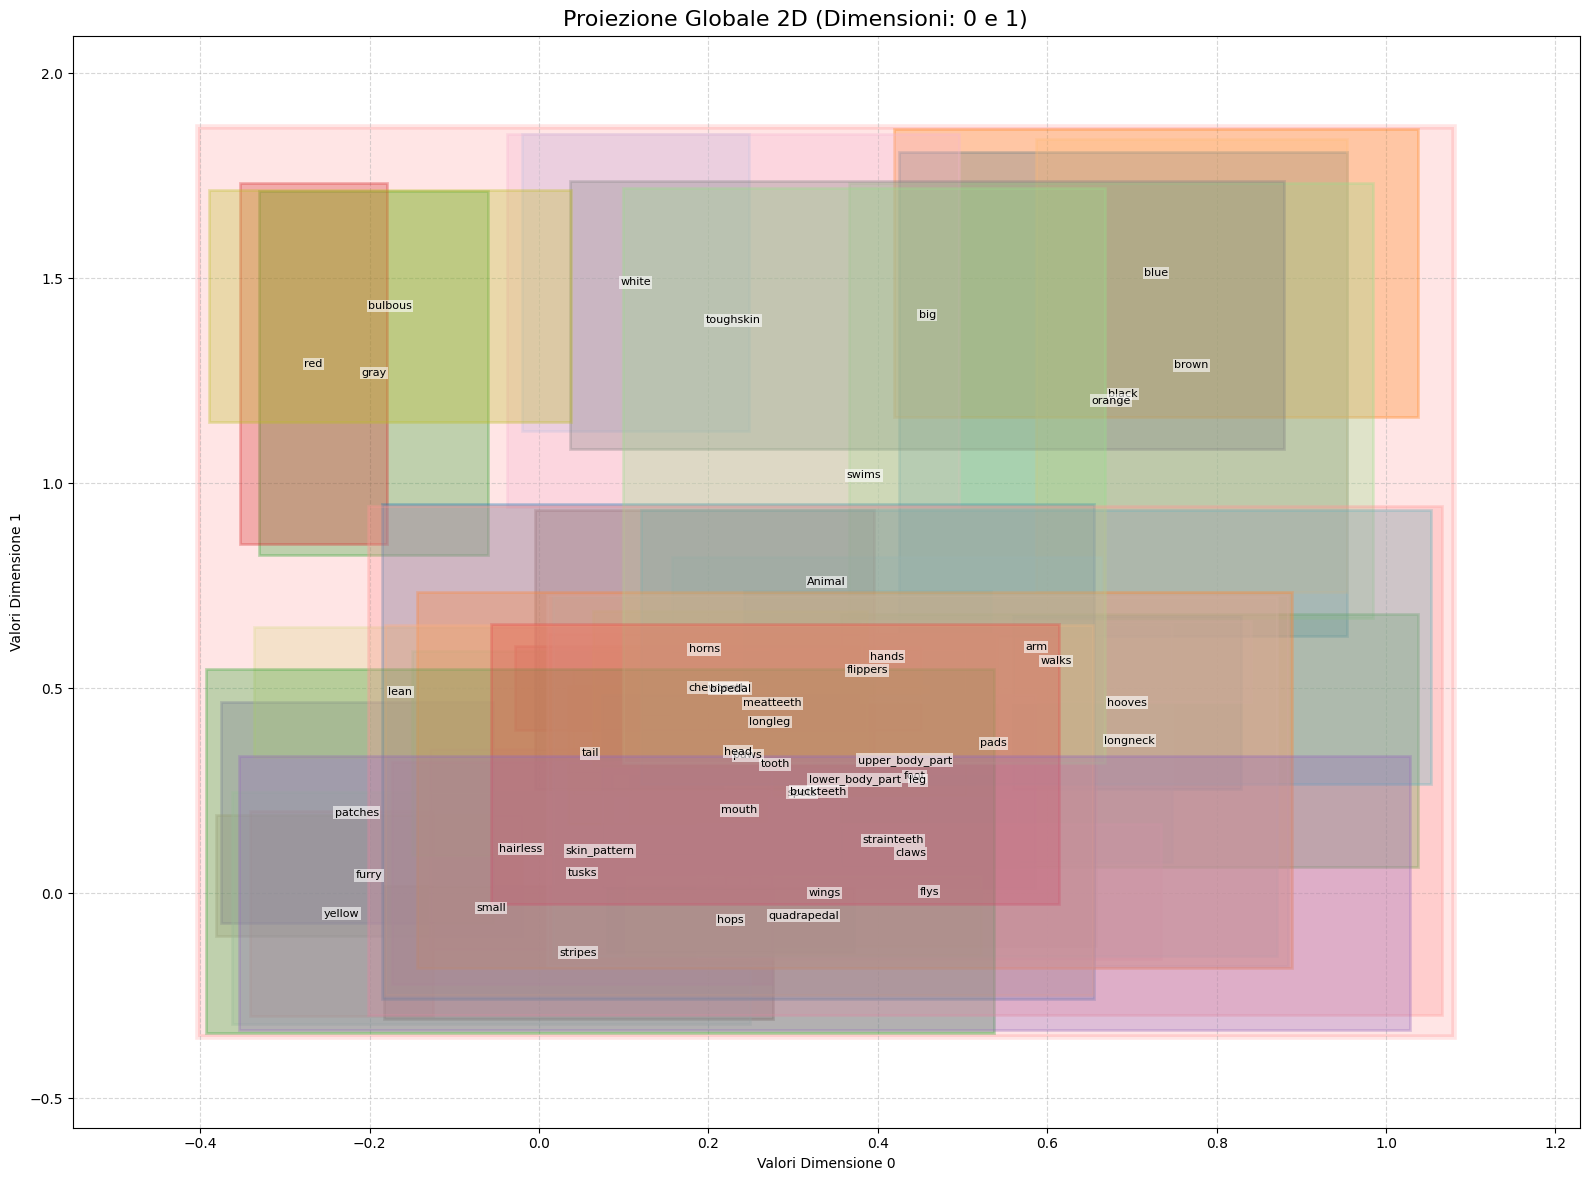

In [11]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

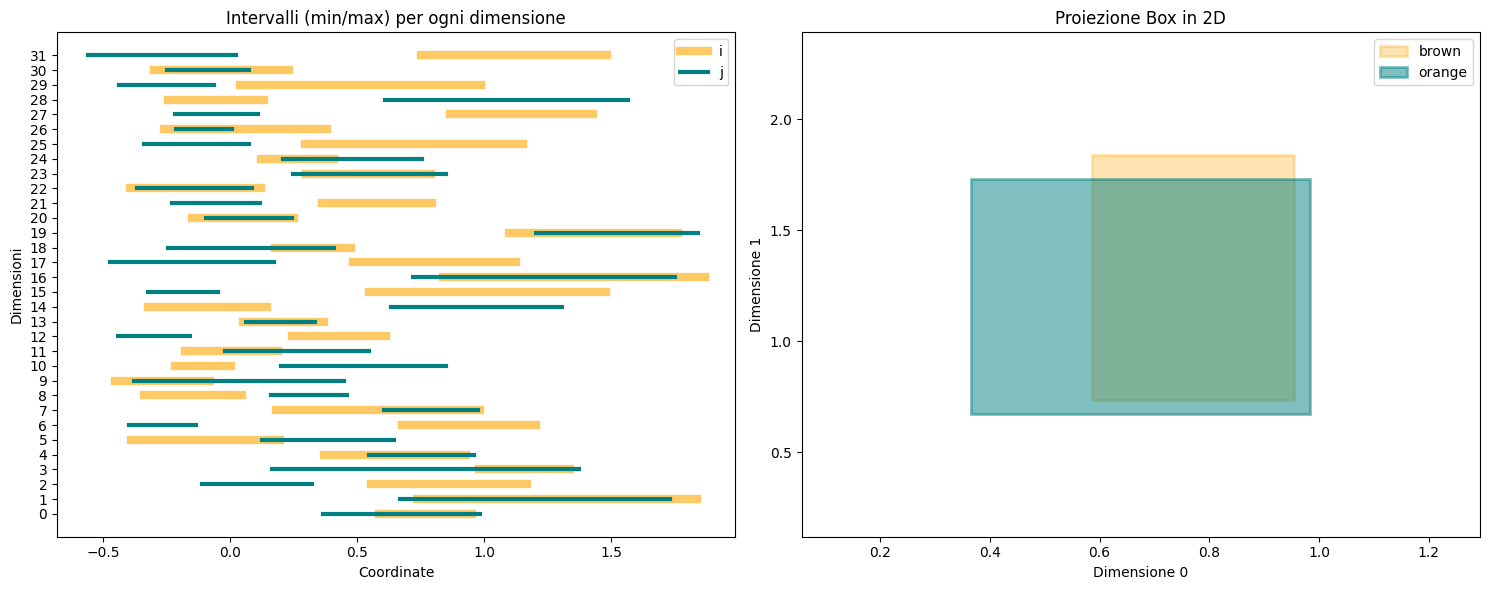

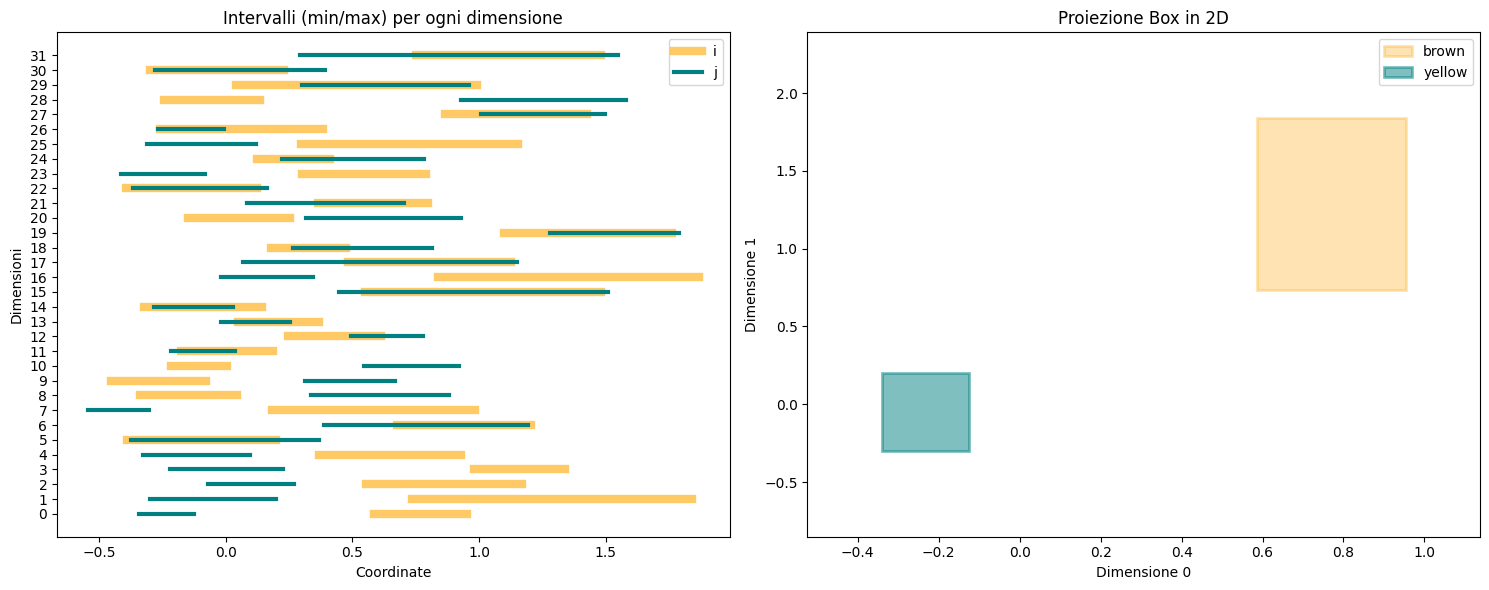

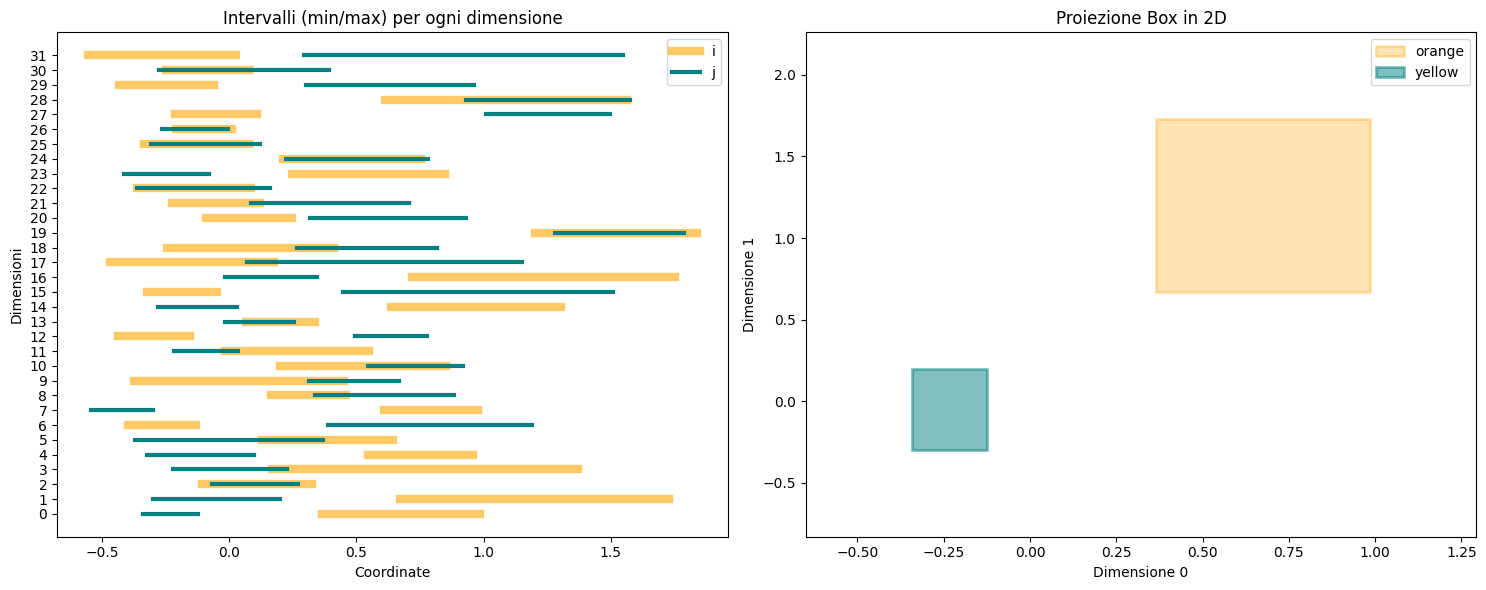

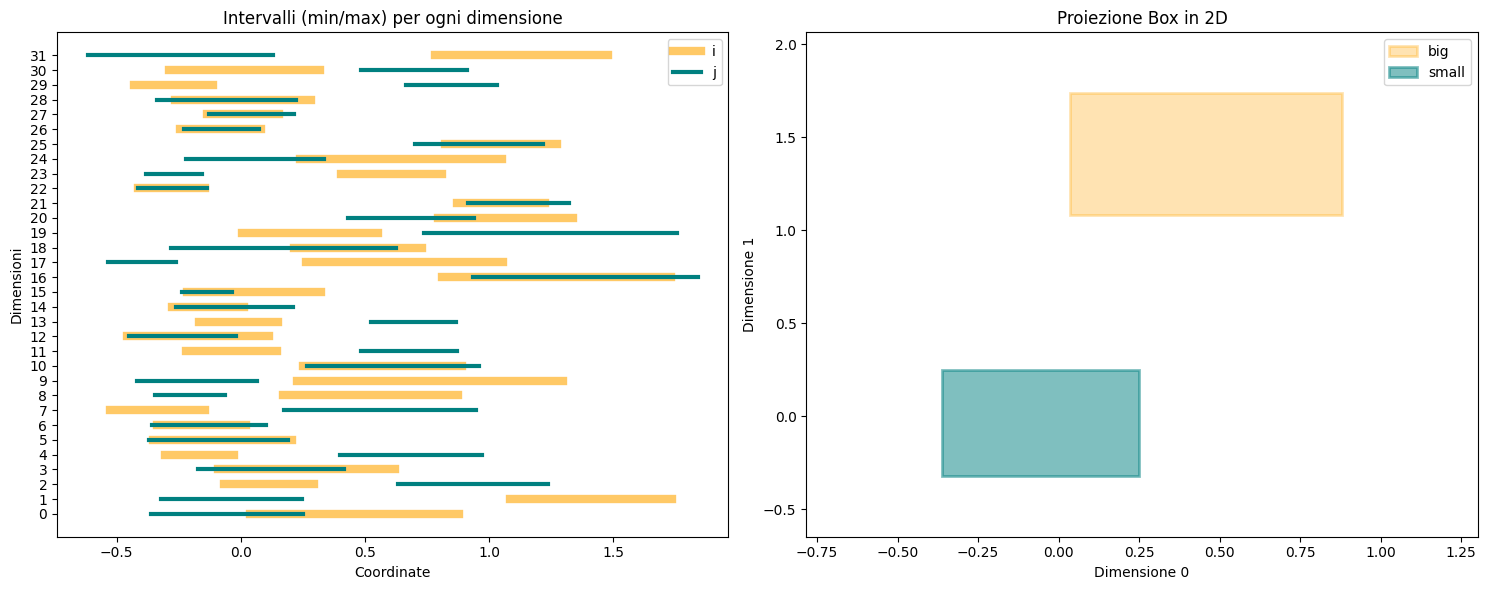

In [12]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [13]:
from src.CHM.model import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

In [14]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.0807, 1.8684, 1.3124, 1.4757, 1.0185, 0.9479, 1.2147, 1.0599, 1.0035,
         1.3414, 1.0406, 0.9318, 0.9099, 0.9997, 1.4805, 1.5508, 1.8738, 1.1993,
         0.9630, 1.8584, 1.4342, 1.3493, 1.0599, 1.0458, 1.1124, 1.3096, 1.1066,
         1.5363, 1.6056, 1.0724, 1.1741, 1.5941]])
Coordinate z (min) per 'wings': tensor([[-0.3542, -0.3331,  0.3417, -0.0345, -0.3466, -0.3935, -0.3706, -0.5792,
         -0.3382,  0.3882, -0.1937,  0.0314, -0.4928, -0.2492, -0.3232,  0.0826,
          0.4532, -0.2682,  0.3687,  0.6254,  0.4632, -0.0284,  0.2816, -0.0352,
         -0.1958, -0.3157, -0.0890,  0.0369,  0.3473, -0.4148, -0.3084, -0.5856]])


## CBM

### Load dataset

In [15]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [16]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [17]:
box_dict = get_box_dict(box_model, id2concept)

In [18]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.0807, 1.8684, 1.3124, 1.4757, 1.0185, 0.9479, 1.2147, 1.0599, 1.0035,
         1.3414, 1.0406, 0.9318, 0.9099, 0.9997, 1.4805, 1.5508, 1.8738, 1.1993,
         0.9630, 1.8584, 1.4342, 1.3493, 1.0599, 1.0458, 1.1124, 1.3096, 1.1066,
         1.5363, 1.6056, 1.0724, 1.1741, 1.5941]])
Coordinate z (min) per 'wings': tensor([[-0.3542, -0.3331,  0.3417, -0.0345, -0.3466, -0.3935, -0.3706, -0.5792,
         -0.3382,  0.3882, -0.1937,  0.0314, -0.4928, -0.2492, -0.3232,  0.0826,
          0.4532, -0.2682,  0.3687,  0.6254,  0.4632, -0.0284,  0.2816, -0.0352,
         -0.1958, -0.3157, -0.0890,  0.0369,  0.3473, -0.4148, -0.3084, -0.5856]])


In [19]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.CHM.model import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [20]:
from src.CHM.model import ConceptBottleneckClassifier, ConceptPredictor
from src.CHM.train import train_cbm_classifier, sequential_training, train_concept_predictor
import matplotlib.pyplot as plt
from src.CHM.test import test_cbm_classifier, plot_test_results, test_sequential_cbm

### CBM with boxes

#### Train

In [21]:
b_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
b_cls_optimizer = torch.optim.Adam(b_cls.parameters(), lr=0.001)
b_cls_criterion = nn.CrossEntropyLoss()

b_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
b_concept_optimizer = torch.optim.Adam(b_concept_predictor.parameters(), lr=0.001)
b_concept_criterion = nn.BCEWithLogitsLoss()

info = "boxes"

b_conc_history, b_cls_history = sequential_training(
    b_cls,
    b_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    b_cls_optimizer,  
    b_concept_optimizer,
    b_cls_criterion,
    b_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.5615 | Acc: 95.9327 || Val Loss: 2.5832 | Val Acc: 97.0640
Loss: 2.2490 | Acc: 97.4241 || Val Loss: 2.3505 | Val Acc: 97.2344
Loss: 1.9618 | Acc: 97.7457 || Val Loss: 2.2099 | Val Acc: 97.4021
Loss: 1.7804 | Acc: 97.9535 || Val Loss: 2.1948 | Val Acc: 97.4573
Loss: 1.6645 | Acc: 98.0759 || Val Loss: 2.1695 | Val Acc: 97.4900
Loss: 1.5665 | Acc: 98.1915 || Val Loss: 2.1615 | Val Acc: 97.5253
Loss: 1.4905 | Acc: 98.2801 || Val Loss: 2.1642 | Val Acc: 97.5028
Loss: 1.4347 | Acc: 98.3451 || Val Loss: 2.1736 | Val Acc: 97.5264
Loss: 1.3873 | Acc: 98.3891 || Val Loss: 2.1500 | Val Acc: 97.5382
Loss: 1.3362 | Acc: 98.4550 || Val Loss: 2.1772 | Val Acc: 97.5092
Loss: 1.2993 | Acc: 98.5024 || Val Loss: 2.1911 | Val Acc: 97.5157
Loss: 1.2713 | Acc: 98.5266 || Val Loss: 2.2618 | Val Acc: 97.4985
Loss: 1.2300 | Acc: 98.5779 || Val Loss: 2.2207 | Val Acc: 97.5350
Loss: 1.2132 | Acc: 98.6047 || Val Loss: 2.2290 | Val Ac

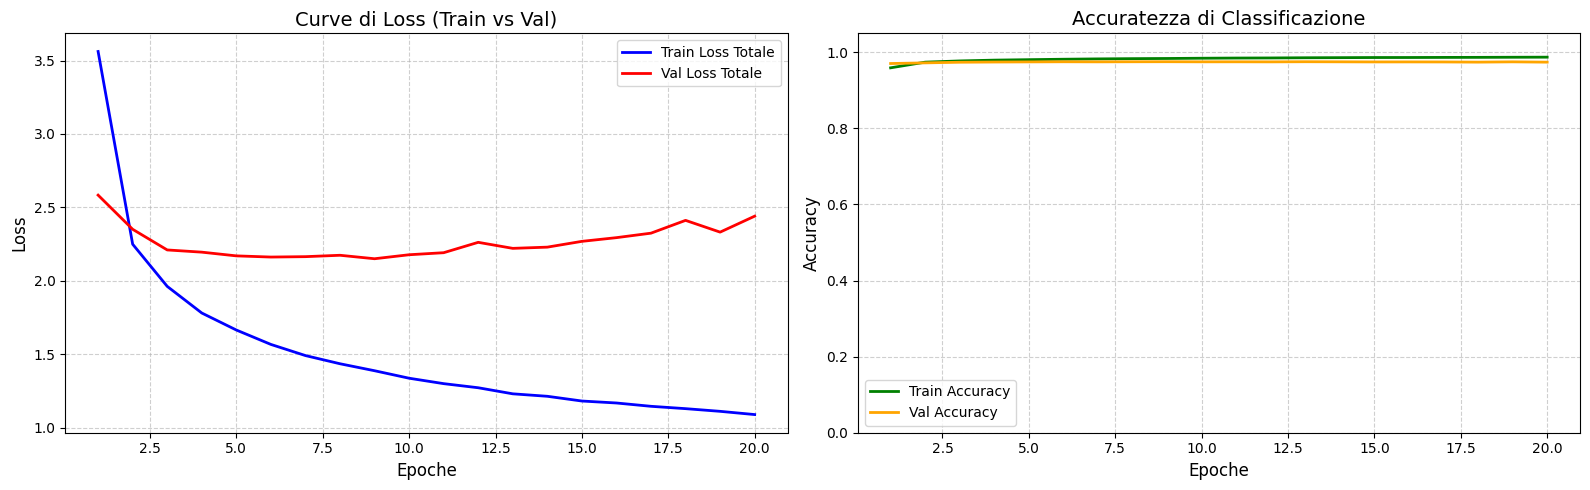

In [22]:
from src.CHM.train import plot_history
plot_history(b_conc_history)

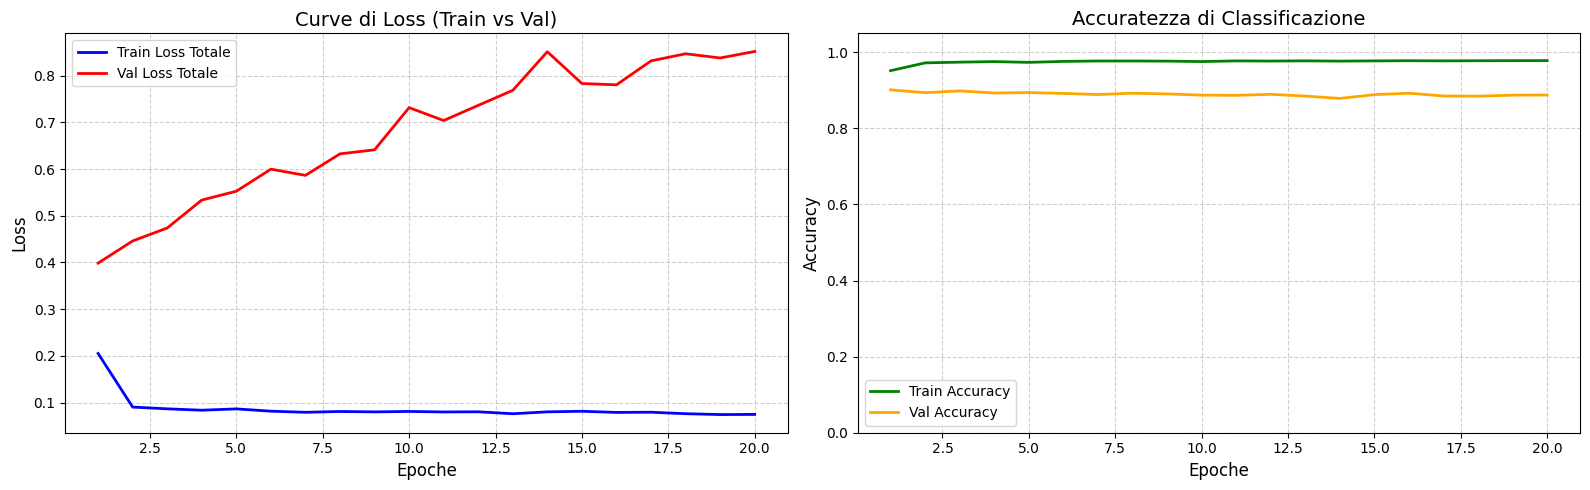

In [23]:
plot_history(b_cls_history)

#### Test

In [24]:
accuracy, preds, labels = test_sequential_cbm(
    b_cls,
    b_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 88.89% (6636/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       209
           1       0.91      0.84      0.87       170
           2       0.81      0.81      0.81        58
           3       0.77      0.79      0.78        38
           4       0.97      0.97      0.97       110
           5       0.93      0.90      0.91       149
           6       0.92      0.93      0.92       329
           7       0.87      0.86      0.87       207
           8       0.32      0.34      0.33        35
           9       0.73      0.83      0.78       100

   micro avg       0.87      0.88      0.87      1405
   macro avg       0.81      0.82      0.81      1405
weighted avg       0.87      0.88      0.87      1405



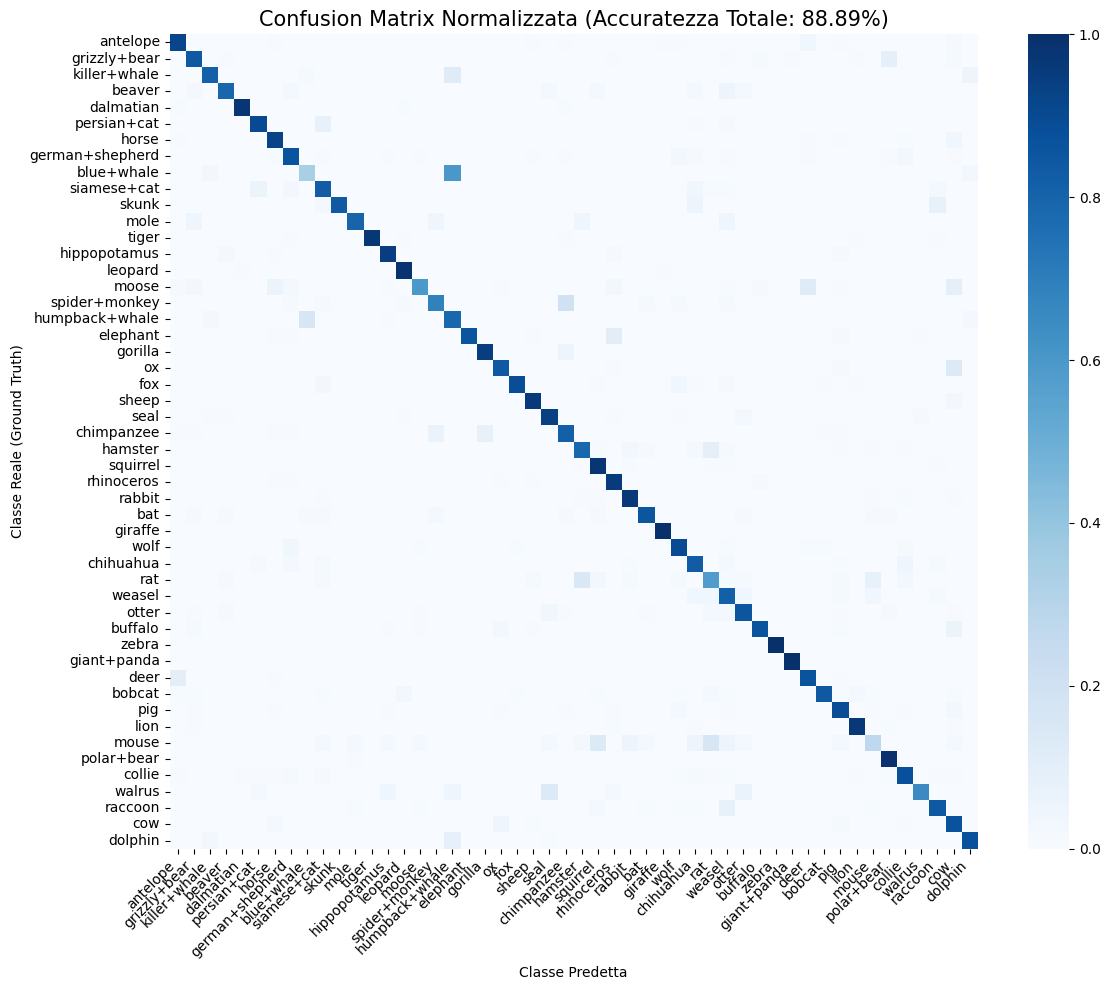


Analisi degli Errori Principali:
 - 28 volte: 'deer' è stato scambiato per 'antelope'
 - 23 volte: 'humpback+whale' è stato scambiato per 'blue+whale'
 - 22 volte: 'elephant' è stato scambiato per 'rhinoceros'
 - 21 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 20 volte: 'ox' è stato scambiato per 'cow'


In [25]:
plot_test_results(accuracy, preds, labels, class_names=classes)

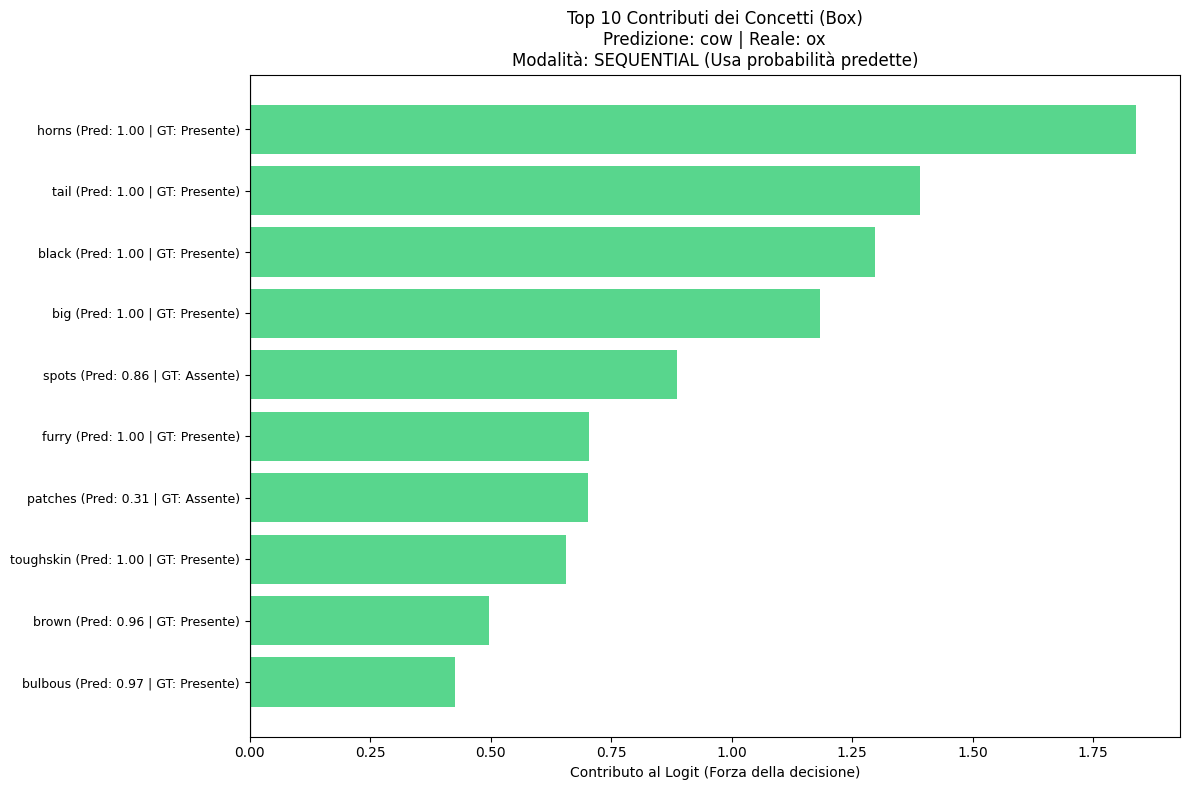

False

In [27]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    b_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=b_concept_predictor,
    target_class="ox"
)

### CBM with cond prob distrib

#### Train

In [ ]:
info = "rel_matrix"
bipolar = True
cp_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(cp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
cp_history = train_cbm_classifier(
    cp_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info,
    bipolar=bipolar
)

In [ ]:
from src.CHM.train import plot_history
plot_history(cp_history)

#### Test

In [ ]:
accuracy, preds, labels = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=bipolar,
     oracle=True,
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_model, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors, 
    info_type=info, 
    target_class="chihuahua", 
    bipolar=bipolar
)

### CBM standard

In [ ]:
info = "concepts"
c_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(c_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
c_history = train_cbm_classifier(
    c_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

In [ ]:
from src.CHM.train import plot_history
plot_history(c_history)

In [ ]:
accuracy, preds, labels = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     oracle=True,
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(c_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)

In [ ]:
from src.CHM.interpretation import visualizza_separabilita, shuffle_test

visualizza_separabilita(
    model=c_model,
    test_dataloader=test_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    info=info,
    bipolar=bipolar
)

In [ ]:
shuffle_test(c_model, test_dataloader, class_concept_matrix, box_tensors, info=info, bipolar=bipolar)

In [ ]:
from src.CHM.model import ConceptPredictor

concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
from src.CHM.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor, 
    train_dataloader, 
    val_dataloader, 
    class_concept_matrix, 
    optimizer, 
    criterion, 
    EPOCHS, 
    device
)

In [ ]:
info = "boxes"
b_accuracy, b_preds, b_labels = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
plot_test_results(b_accuracy, b_preds, b_labels, class_names=classes)

In [ ]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

In [ ]:
info = "concepts"
c_accuracy, c_preds, c_labels = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)